# Stroke Prediction: Deep Learning vs Classical ML

This notebook compares the 10 classical machine learning models evaluated under various sampling strategies (Exp0: Baseline, Exp1: Class Weighting, Exp2: SMOTE) against the newly developed PyTorch MLP deep learning baseline with BCE, Weighted BCE, and Focal Loss.

In [ ]:
#Test Python environment and imports
import sys
print(sys.executable)

import os
import pandas as pd

print("OK")

/Users/ece/Desktop/ml/cs464-project/.venv/bin/python
OK


In [2]:
import pandas as pd
import numpy as np
import os
import matplotlib.pyplot as plt
import seaborn as sns

# Attempt to use shared visual settings if available
import sys
sys.path.append('..')
try:
    import shared
    shared.setup_plot_style()
except ImportError:
    plt.rcParams.update({'figure.figsize': (10, 6)})

### 1. Load All Results

In [3]:
# Define paths to the test_results.csv files
base_url = '../../outputs/results'
paths = {
    'Classical (Baseline)': f'{base_url}/exp0_baseline/test_results.csv',
    'Classical (Class Weight)': f'{base_url}/exp1_class_weight/test_results.csv',
    'Classical (SMOTE)': f'{base_url}/exp2_smote/test_results.csv',
    'PyTorch MLP': f'{base_url}/dl_mlp/test_results.csv'
}

dfs = []
for strategy, path in paths.items():
    if os.path.exists(path):
        df = pd.read_csv(path)
        df['Strategy_Group'] = strategy
        dfs.append(df)
    else:
        print(f"Warning: Could not find {path}")
        
combined_df = pd.concat(dfs, ignore_index=True) if dfs else pd.DataFrame()
combined_df['Model_Strategy'] = combined_df['Model'] + " [" + combined_df['Strategy_Group'] + "]"

print(f"Loaded {len(combined_df)} model results.")
combined_df.head()

Loaded 33 model results.


,Model,Accuracy,F1,Recall,Precision,AUC-ROC,AUC-PR,Strategy_Group,Model_Strategy
0,Logistic Regression,0.9521,0.0392,0.02,1.0000,0.8428,0.2627,Classical (Baseline),Logistic Regression [Classical (Baseline)]
1,Gaussian NB,0.3112,0.1222,0.98,0.0652,0.7859,0.1550,Classical (Baseline),Gaussian NB [Classical (Baseline)]
2,KNN (k=1),0.9188,0.0460,0.04,0.0541,0.5020,0.0491,Classical (Baseline),KNN (k=1) [Classical (Baseline)]
3,KNN (k=3),0.9442,0.0656,0.04,0.1818,0.5279,0.0569,Classical (Baseline),KNN (k=3) [Classical (Baseline)]
4,KNN (k=5),0.9491,0.0000,0.00,0.0000,0.5912,0.0654,Classical (Baseline),KNN (k=5) [Classical (Baseline)]


### 2. Ranked by F1-Score

In [4]:
top_f1 = combined_df.sort_values(by='F1', ascending=False)[['Model', 'Strategy_Group', 'F1', 'Recall', 'Precision', 'AUC-ROC', 'AUC-PR']]
display(top_f1.head(15).style.background_gradient(cmap='Greens', subset=['F1', 'Recall', 'AUC-PR']))

,Model,Strategy_Group,F1,Recall,Precision,AUC-ROC,AUC-PR
10,Logistic Regression,Classical (Class Weight),0.244600,0.800000,0.144400,0.842800,0.260800
20,Logistic Regression,Classical (SMOTE),0.239300,0.780000,0.141300,0.844500,0.266500
17,SVM (RBF),Classical (Class Weight),0.235300,0.680000,0.142300,0.808600,0.176800
31,PyTorch MLP (Weighted),PyTorch MLP,0.230800,0.780000,0.135400,0.839000,0.269300
27,SVM (RBF),Classical (SMOTE),0.213000,0.460000,0.138600,0.783600,0.166600
25,KNN (k=7),Classical (SMOTE),0.168200,0.360000,0.109800,0.666500,0.079500
26,KNN (k=9),Classical (SMOTE),0.166700,0.400000,0.105300,0.687600,0.085300
22,KNN (k=1),Classical (SMOTE),0.152500,0.180000,0.132400,0.559700,0.063900
23,KNN (k=3),Classical (SMOTE),0.147200,0.240000,0.106200,0.563800,0.062300
24,KNN (k=5),Classical (SMOTE),0.145100,0.280000,0.097900,0.618600,0.069700


### 3. Ranked by AUC-PR

In [5]:
top_pr = combined_df.sort_values(by='AUC-PR', ascending=False)[['Model', 'Strategy_Group', 'AUC-PR', 'AUC-ROC', 'F1', 'Recall']]
display(top_pr.head(15).style.background_gradient(cmap='Blues', subset=['AUC-PR', 'AUC-ROC', 'F1']))

,Model,Strategy_Group,AUC-PR,AUC-ROC,F1,Recall
31,PyTorch MLP (Weighted),PyTorch MLP,0.269300,0.839000,0.230800,0.780000
20,Logistic Regression,Classical (SMOTE),0.266500,0.844500,0.239300,0.780000
0,Logistic Regression,Classical (Baseline),0.262700,0.842800,0.039200,0.020000
10,Logistic Regression,Classical (Class Weight),0.260800,0.842800,0.244600,0.800000
32,PyTorch MLP (Focal),PyTorch MLP,0.243100,0.840700,0.000000,0.000000
30,PyTorch MLP (BCE),PyTorch MLP,0.236400,0.837200,0.000000,0.000000
17,SVM (RBF),Classical (Class Weight),0.176800,0.808600,0.235300,0.680000
19,XGBoost,Classical (Class Weight),0.169500,0.780600,0.128200,0.100000
29,XGBoost,Classical (SMOTE),0.167100,0.786700,0.111100,0.100000
27,SVM (RBF),Classical (SMOTE),0.166600,0.783600,0.213000,0.460000


### 4. Exp2 (SMOTE vs Weighted) Deep Learning Breakdown

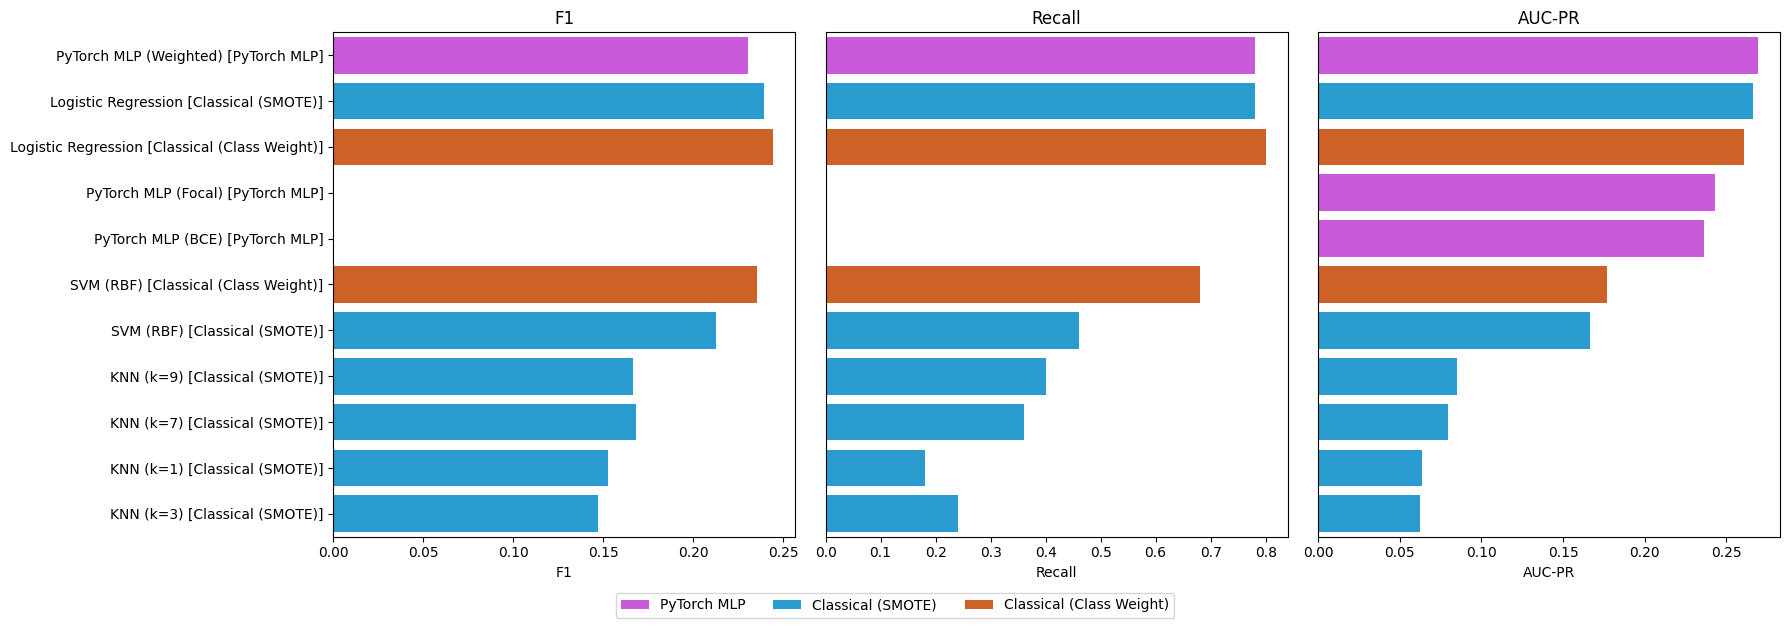

In [6]:
exp2_dl = combined_df[combined_df['Strategy_Group'].isin(['Classical (SMOTE)', 'PyTorch MLP', 'Classical (Class Weight)'])]

# Keep only the top 5 classical and all Deep learning models for a clean plot
dl_rows = exp2_dl[exp2_dl['Strategy_Group'] == 'PyTorch MLP']
classical_rows = exp2_dl[exp2_dl['Strategy_Group'].isin(['Classical (SMOTE)', 'Classical (Class Weight)'])].sort_values('F1', ascending=False).head(8)

compare_df = pd.concat([dl_rows, classical_rows]).sort_values('AUC-PR', ascending=False)

fig, axes = plt.subplots(1, 3, figsize=(18, 6))

metrics = ['F1', 'Recall', 'AUC-PR']
colors = {'PyTorch MLP': '#d946ef', 'Classical (SMOTE)': '#0ea5e9', 'Classical (Class Weight)': '#ea580c'}

for i, metric in enumerate(metrics):
    sns.barplot(data=compare_df, y='Model_Strategy', x=metric, hue='Strategy_Group', 
                ax=axes[i], dodge=False, palette=colors)
    axes[i].set_title(metric)
    axes[i].set_ylabel('')
    if i > 0:
        axes[i].set_yticks([])
    axes[i].legend_.remove()

handles, labels = axes[0].get_legend_handles_labels()
fig.legend(handles, labels, loc='lower center', ncol=3, bbox_to_anchor=(0.5, -0.05))
plt.tight_layout()
plt.show()